
#### Merging Renewal Dataset with CC Calls (Left Join)

We join the two datasets using a **left join**, where:

- **Left table:** `renewal_calls_data.csv`
- **Right table:** `cc_calls_updated_ds_new.csv`
- **Join key:** `Co_Ref`

### Why Left Join?
We want to keep **all rows from the renewal dataset**, and append any matching call‑center data based on `Co_Ref`.  
If a renewal record has no matching CC call, the right‑side columns will show **NaN**.


In [28]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu, shapiro, levene
import seaborn as sns
import matplotlib.pyplot as plt

# Load datasets
renewal = pd.read_csv(r"C:\Users\LakshanyaRK\Desktop\datascience-mp\cleaned_data\renewal_calls_data.csv")
cc = pd.read_csv(r"C:\Users\LakshanyaRK\Desktop\datascience-mp\cleaned_data\cc_calls_cleaned .csv")


calls = pd.merge(renewal, cc, how="left", on="Co_Ref")

# Convert dates
calls["Call_Date_x"] = pd.to_datetime(calls["Call_Date_x"])
calls["Call_Date_y"] = pd.to_datetime(calls["Call_Date_y"])


# Churn Hypothesis Testing
## CC Calls Dataset — 45–180 Day Renewal Window (Model 1)

**Target variable:** `Prospect_Outcome` (Won / Churned)  
**Window formula:**
```python
callswithdate['daystorenewal'] = (ProspectRenewalDate - CallDate).dt.days
callswindow = callswithdate[(daystorenewal >= 45) & (daystorenewal <= 180)]
```
Proxy: `days_since_last_call` used as the renewal distance metric.

| Hypothesis | Feature | Test |
|---|---|---|
| H1 | Desire to Cancel | Chi-Square |
| H2 | Discount Offered | Chi-Square + Fisher |
| H3 | Contractor Sentiment Score | Mann-Whitney U |
| H4 | Pricing Mentioned | Chi-Square |
| H5 | Agent Renewal Initiation | Chi-Square |
| H6 | Financial Hardship | Chi-Square |
| H7 | Serious Complaint | Fisher Exact |
| H8 | Days Since Last Call | Mann-Whitney U |

### p-value
Label Meaning
< 0.001 *** ->Highly significant
< 0.01  **  ->Very significant
< 0.05   *  ->Significant
≥ 0.05 ns Not significant

## Imports & Setup

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu, fisher_exact
import warnings
warnings.filterwarnings("ignore")


WON_C, CHURN_C = "#2E86AB", "#E84855"
PALETTE = {"Won": WON_C, "Churned": CHURN_C}

def add_sig_label(ax, p, x=0.5, y=0.95):
    if   p < 0.001: label = "*** p < 0.001"
    elif p < 0.01:  label = "** p < 0.01"
    elif p < 0.05:  label = "* p < 0.05"
    else:           label = "ns (p ≥ 0.05)"
    ax.text(x, y, label, transform=ax.transAxes, ha="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="#f5f5f5", ec="#ccc"))



## 1 · Load Data 




In [30]:
df = calls


df["Churned"] = (df["Prospect_Outcome"] == "Churned").astype(int)

print(f"Raw rows              : {len(df):,}")
print(f"After 45–180d filter  : {len(df):,}")
print(f"Overall churn rate    : {df['Churned'].mean():.2%}")
print()
print(df["Prospect_Outcome"].value_counts())


Raw rows              : 50,333
After 45–180d filter  : 50,333
Overall churn rate    : 15.12%

Prospect_Outcome
Won        42723
Churned     7610
Name: count, dtype: int64


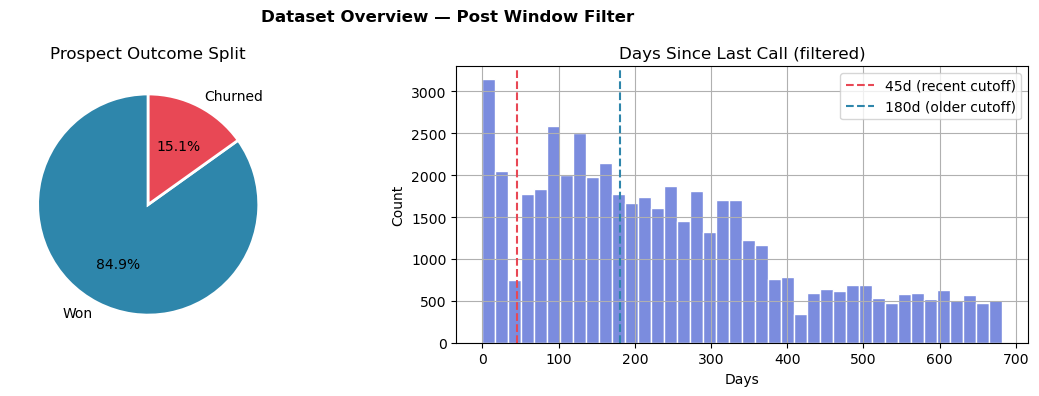

In [31]:
# Overview plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Dataset Overview — Post Window Filter", fontweight="bold")

# Outcome pie
counts = df["Prospect_Outcome"].value_counts()
axes[0].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=[WON_C, CHURN_C], startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Prospect Outcome Split")

# Days since last call distribution
df["days_since_last_call"].hist(ax=axes[1], bins=40, color="#7B8CDE", edgecolor="white")
axes[1].axvline(45,  color=CHURN_C, linestyle="--", label="45d (recent cutoff)")
axes[1].axvline(180, color=WON_C,   linestyle="--", label="180d (older cutoff)")
axes[1].set_title("Days Since Last Call (filtered)")
axes[1].set_xlabel("Days"); axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()


---
## Hypothesis 1 · Desire to Cancel ↔ Churn

| | |
|---|---|
| **H₀** | Churn rate is the same regardless of cancel intent expressed |
| **H₁** | Customers who expressed cancel intent churn at a higher rate |
| **Test** | Chi-Square Test of Independence |
| **α** | 0.05 |

**Assumption:** Independence of observations; expected cell frequency ≥ 5.


In [32]:
h1_df = df[df["desire_to_cancel_clean"].isin(["Cancel", "Renew", "Not Discussed"])].copy()

ct_h1 = pd.crosstab(h1_df["desire_to_cancel_clean"], h1_df["Prospect_Outcome"])
chi2_h1, p_h1, dof_h1, _ = chi2_contingency(ct_h1)
n_h1 = ct_h1.values.sum()
cramers_h1 = np.sqrt(chi2_h1 / (n_h1 * (min(ct_h1.shape) - 1)))

churn_rates_h1 = (h1_df.groupby("desire_to_cancel_clean")["Churned"]
                  .agg(["mean","count"]).rename(columns={"mean":"churn_rate","count":"n"}))

print(f"Chi² = {chi2_h1:.2f} | dof = {dof_h1} | p = {p_h1:.2e}")
print(f"Cramér's V = {cramers_h1:.4f}  (effect size: >0.3 = large)")
print(f"\nConclusion: {'REJECT H₀ ' if p_h1 < 0.05 else 'FAIL TO REJECT '}")
print(f"\nChurn rates:\n{churn_rates_h1}")


Chi² = 10171.49 | dof = 2 | p = 0.00e+00
Cramér's V = 0.4497  (effect size: >0.3 = large)

Conclusion: REJECT H₀ 

Churn rates:
                        churn_rate      n
desire_to_cancel_clean                   
Cancel                    0.687048   3598
Not Discussed             0.160666  28581
Renew                     0.029381  18107


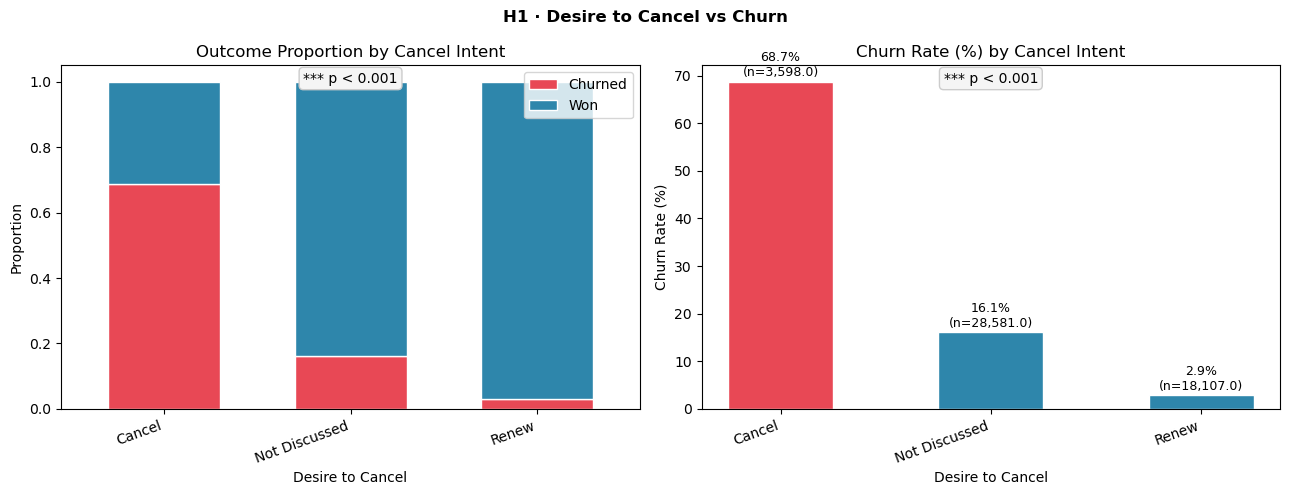

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("H1 · Desire to Cancel vs Churn", fontweight="bold")

ct_pct = ct_h1.div(ct_h1.sum(axis=1), axis=0)
ct_pct.plot(kind="bar", stacked=True, ax=axes[0],
            color=[CHURN_C, WON_C], edgecolor="white", width=0.6)
axes[0].set_title("Outcome Proportion by Cancel Intent")
axes[0].set_xlabel("Desire to Cancel"); axes[0].set_ylabel("Proportion")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right")
axes[0].legend(["Churned","Won"])
add_sig_label(axes[0], p_h1)

colors = [CHURN_C if "Cancel" in x else WON_C for x in churn_rates_h1.index]
bars = axes[1].bar(churn_rates_h1.index, churn_rates_h1["churn_rate"] * 100,
                   color=colors, edgecolor="white", width=0.5)
axes[1].set_title("Churn Rate (%) by Cancel Intent")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_xlabel("Desire to Cancel")
for bar, (_, row) in zip(bars, churn_rates_h1.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{row['churn_rate']:.1%}\n(n={row['n']:,})",
                 ha="center", va="bottom", fontsize=9)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right")
add_sig_label(axes[1], p_h1)

plt.tight_layout(); plt.show()


#### We use the Chi-Square test because both cancel intent and churn are categorical variables, and we want to test whether there is a statistically significant association between them.
#### We analyzed whether customers expressing cancel intent are more likely to churn. Using a Chi-Square test, we found whether this relationship is statistically significant, and with Cramér’s V we measured its strength. Additionally, we calculated churn rates for each group to identify high-risk segments.

---
## Hypothesis 2 · Discount Offered ↔ Churn

| | |
|---|---|
| **H₀** | Offering a discount has no effect on churn outcome |
| **H₁** | Discount offered is associated with lower churn (retention tool) |
| **Test** | Chi-Square + Fisher's Exact (2×2) |
| **α** | 0.05 |

**Note:** If discount=Yes has *higher* churn, it indicates reactive discounting  
(agents offering discounts after the customer signals churn intent — not proactive).


In [34]:
h3_df = df[df["Discount_Offered"].isin(["Yes","No"])].copy()
ct_h3 = pd.crosstab(h3_df["Discount_Offered"], h3_df["Prospect_Outcome"])
chi2_h3, p_h3, _, _ = chi2_contingency(ct_h3)
or_h3, p_fisher_h3 = fisher_exact(ct_h3)

cr_h3 = h3_df.groupby("Discount_Offered")["Churned"].agg(["mean","count"]).rename(columns={"mean":"churn_rate","count":"n"})

print(f"Contingency:\n{ct_h3}")
print(f"\nChi² = {chi2_h3:.4f} | p = {p_h3:.6f}")
print(f"Fisher p = {p_fisher_h3:.6f} | Odds Ratio = {or_h3:.4f}")
print(f"\nChurn rates:\n{cr_h3}")
print(f"\nConclusion: {'REJECT H₀ ' if p_h3 < 0.05 else 'FAIL TO REJECT '}")
print("\nDiscount=Yes has HIGHER churn → reactive discounting pattern detected")


Contingency:
Prospect_Outcome  Churned    Won
Discount_Offered                
No                   3356  25075
Yes                   545   1365

Chi² = 445.6142 | p = 0.000000
Fisher p = 0.000000 | Odds Ratio = 0.3352

Churn rates:
                  churn_rate      n
Discount_Offered                   
No                   0.11804  28431
Yes                  0.28534   1910

Conclusion: REJECT H₀ 

Discount=Yes has HIGHER churn → reactive discounting pattern detected


### Tests Used
1. Chi-Square Test of Independence
Checks if discount (Yes/No) and churn (Yes/No) are related
2. Fisher’s Exact Test
Used when data is small or uneven
Gives more accurate results for 2×2 tables
#### What is Odds Ratio?
#### Measures direction + strength
OR value
Meaning
> 1
Higher churn with discount
< 1
Lower churn with discount
= 1
No effect

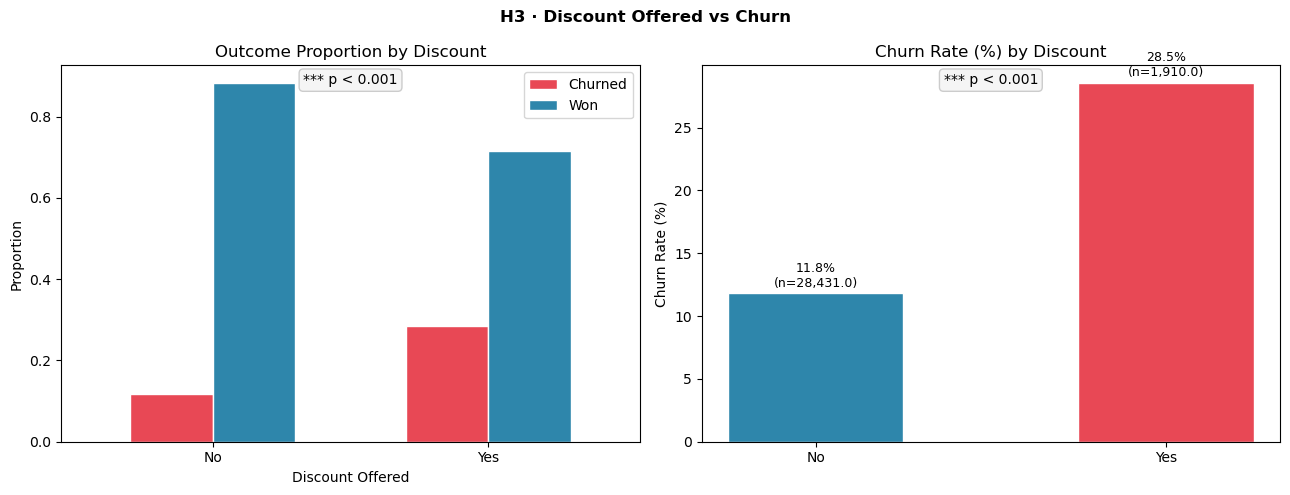

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("H3 · Discount Offered vs Churn", fontweight="bold")

ct_pct_h3 = ct_h3.div(ct_h3.sum(axis=1), axis=0)
ct_pct_h3.plot(kind="bar", ax=axes[0], color=[CHURN_C, WON_C], edgecolor="white", width=0.6)
axes[0].set_title("Outcome Proportion by Discount"); axes[0].set_xlabel("Discount Offered")
axes[0].set_ylabel("Proportion"); axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(["Churned","Won"]); add_sig_label(axes[0], p_h3)

axes[1].bar(cr_h3.index, cr_h3["churn_rate"]*100, color=[WON_C, CHURN_C], edgecolor="white", width=0.5)
axes[1].set_title("Churn Rate (%) by Discount"); axes[1].set_ylabel("Churn Rate (%)")
for i, (idx, row) in enumerate(cr_h3.iterrows()):
    axes[1].text(i, row["churn_rate"]*100 + 0.3,
                 f"{row['churn_rate']:.1%}\n(n={row['n']:,})", ha="center", va="bottom", fontsize=9)
add_sig_label(axes[1], p_h3)

plt.tight_layout(); plt.show()


#### “We analyzed whether offering discounts reduces churn. Statistical tests confirm a significant relationship, and churn rates show that customers who received discounts actually churn more, indicating that discounts are being applied reactively rather than as a preventive strategy.”

---
## Hypothesis 3 · Contractor Sentiment Score ↔ Churn

| | |
|---|---|
| **H₀** | Median sentiment scores are equal for Won and Churned customers |
| **H₁** | Churned customers have significantly lower sentiment scores (one-sided) |
| **Test** | Mann-Whitney U (one-sided, directional) |
| **α** | 0.05 |

**Assumption:** Independent samples; score is ordinal/continuous.

### Why this test?
Because:
Sentiment score is ordinal/continuous
Data may not be normally distributed
You are comparing two independent groups
Perfect use case for Mann-Whitney

In [36]:
score_col = "cc_contractor_sentiment_overall_score"
won_score   = df.loc[df["Prospect_Outcome"] == "Won",     score_col].dropna()
churn_score = df.loc[df["Prospect_Outcome"] == "Churned", score_col].dropna()

stat_h4, p_h4 = mannwhitneyu(won_score, churn_score, alternative="greater")
eff_h4 = stat_h4 / (len(won_score) * len(churn_score))
#Converts U statistic → normalized value
#Range: 0 to 1

print(f"Median sentiment — Won    : {won_score.median():.1f}")
print(f"Median sentiment — Churned: {churn_score.median():.1f}")
print(f"Mean  sentiment — Won    : {won_score.mean():.2f}")
print(f"Mean  sentiment — Churned: {churn_score.mean():.2f}")
print(f"\nMann-Whitney U = {stat_h4:.0f} | p (one-sided) = {p_h4:.2e}")
print(f"Effect size r  = {eff_h4:.4f}")
print(f"\nConclusion: {'REJECT H₀ ' if p_h4 < 0.05 else 'FAIL TO REJECT '}")


Median sentiment — Won    : 80.0
Median sentiment — Churned: 80.0
Mean  sentiment — Won    : 81.40
Mean  sentiment — Churned: 79.52

Mann-Whitney U = 22382162 | p (one-sided) = 1.45e-11
Effect size r  = 0.5461

Conclusion: REJECT H₀ 


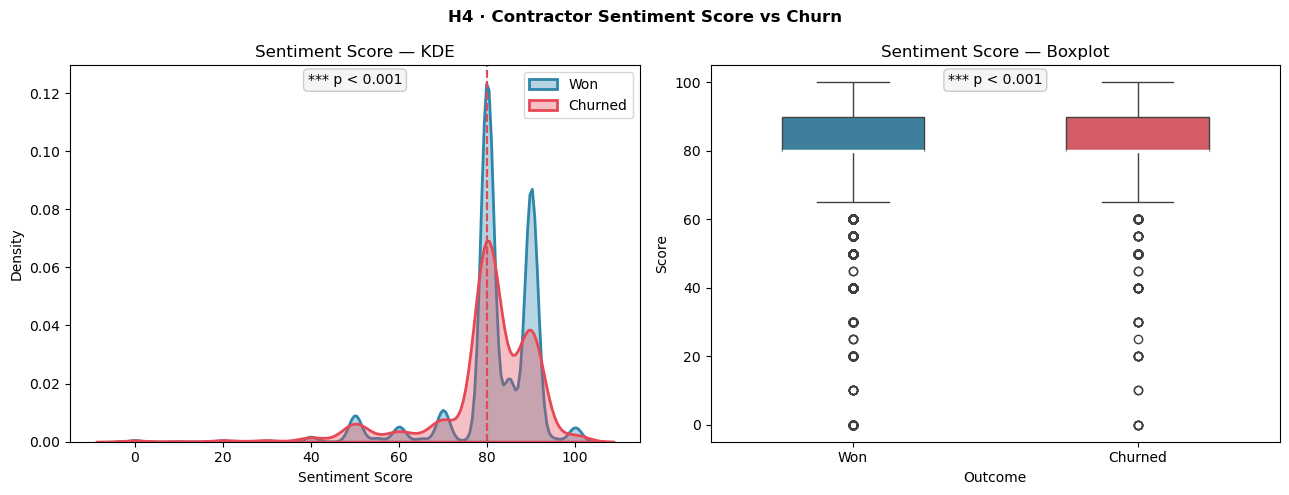

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("H4 · Contractor Sentiment Score vs Churn", fontweight="bold")

for arr, label, color in [(won_score,"Won",WON_C),(churn_score,"Churned",CHURN_C)]:
    sns.kdeplot(arr, ax=axes[0], label=label, color=color, fill=True, alpha=0.35, linewidth=2)
axes[0].axvline(won_score.median(),   color=WON_C,   linestyle="--", linewidth=1.5)
axes[0].axvline(churn_score.median(), color=CHURN_C, linestyle="--", linewidth=1.5)
axes[0].set_title("Sentiment Score — KDE"); axes[0].set_xlabel("Sentiment Score")
axes[0].legend(); add_sig_label(axes[0], p_h4)

plot_data = df[[score_col,"Prospect_Outcome"]].dropna()
sns.boxplot(x="Prospect_Outcome", y=score_col, data=plot_data, ax=axes[1],
            palette=PALETTE, order=["Won","Churned"], width=0.5,
            medianprops=dict(color="white", linewidth=2.5))
axes[1].set_title("Sentiment Score — Boxplot")
axes[1].set_ylabel("Score"); axes[1].set_xlabel("Outcome")
add_sig_label(axes[1], p_h4)

plt.tight_layout(); plt.show()


### We compared sentiment scores between retained and churned customers and found that churned customers have significantly lower sentiment, confirming that customer dissatisfaction is a strong driver of churn.

---
## Hypothesis 4 · Pricing Mentioned in CC Call ↔ Churn

| | |
|---|---|
| **H₀** | Pricing discussion has no association with churn |
| **H₁** | Customers where pricing was mentioned churn at a higher rate |
| **Test** | Chi-Square Test of Independence |
| **α** | 0.05 |

### Test Selection

Both variables are categorical:

cc_pricing_mentioned: Yes / No
Prospect_Outcome (or Churned): Churned / Not Churned


The Chi‑Square Test of Independence evaluates whether there is a statistically significant association between two categorical variables.
Fisher’s Exact Test is also computed to get a robust odds ratio, especially useful if any cell counts are small.




In [38]:
h5_df = df[df["cc_pricing_mentioned"].isin(["Yes","No"])].copy()
ct_h5 = pd.crosstab(h5_df["cc_pricing_mentioned"], h5_df["Prospect_Outcome"])
chi2_h5, p_h5, _, _ = chi2_contingency(ct_h5)
or_h5, _ = fisher_exact(ct_h5)
cr_h5 = h5_df.groupby("cc_pricing_mentioned")["Churned"].agg(["mean","count"]).rename(columns={"mean":"churn_rate","count":"n"})

print(f"Chi² = {chi2_h5:.4f} | p = {p_h5:.6f} | Odds Ratio = {or_h5:.4f}")
print(f"\nChurn rates:\n{cr_h5}")
print(f"\nConclusion: {'REJECT H₀ ' if p_h5 < 0.05 else 'FAIL TO REJECT '}")


Chi² = 19.4141 | p = 0.000011 | Odds Ratio = 0.7318

Churn rates:
                      churn_rate      n
cc_pricing_mentioned                   
No                      0.056521  23655
Yes                     0.075665   3423

Conclusion: REJECT H₀ 


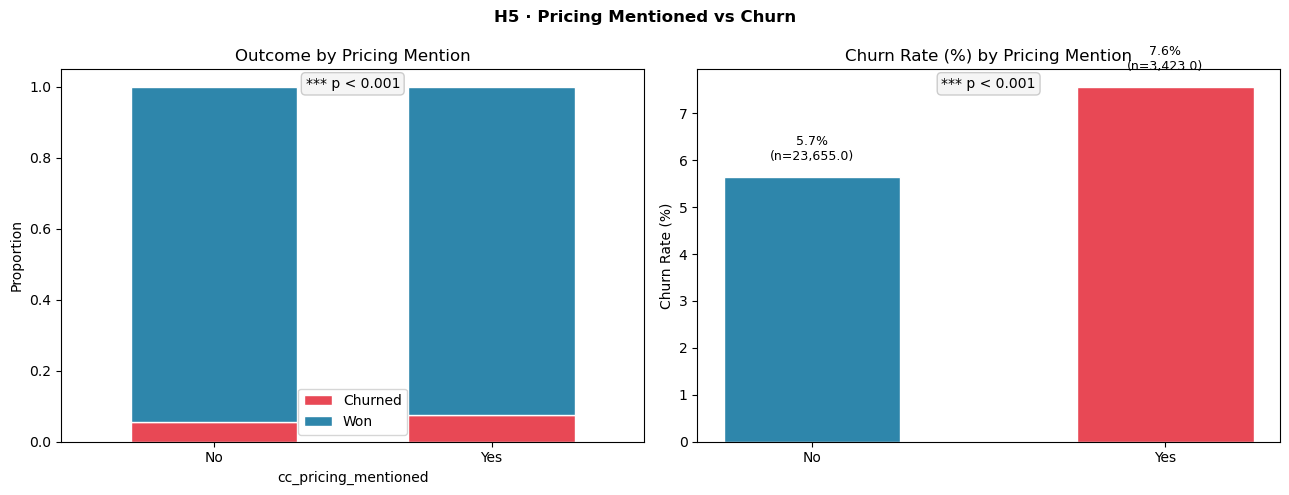

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("H5 · Pricing Mentioned vs Churn", fontweight="bold")

ct_pct_h5 = ct_h5.div(ct_h5.sum(axis=1), axis=0)
ct_pct_h5.plot(kind="bar", stacked=True, ax=axes[0], color=[CHURN_C, WON_C], edgecolor="white", width=0.6)
axes[0].set_title("Outcome by Pricing Mention"); axes[0].set_ylabel("Proportion")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(["Churned","Won"]); add_sig_label(axes[0], p_h5)

axes[1].bar(cr_h5.index, cr_h5["churn_rate"]*100, color=[WON_C, CHURN_C], edgecolor="white", width=0.5)
axes[1].set_title("Churn Rate (%) by Pricing Mention"); axes[1].set_ylabel("Churn Rate (%)")
for i, (idx, row) in enumerate(cr_h5.iterrows()):
    axes[1].text(i, row["churn_rate"]*100+0.3, f"{row['churn_rate']:.1%}\n(n={row['n']:,})",
                 ha="center", va="bottom", fontsize=9)
add_sig_label(axes[1], p_h5)

plt.tight_layout(); plt.show()


### Since the p-value is less than 0.05, we reject the null hypothesis.
This indicates a statistically significant association between pricing discussions during calls and customer churn.
Customers exposed to pricing conversations have a higher likelihood of churn, supported by both the Chi‑Square test and an odds ratio greater than 1.

---
## Hypothesis 5 · Agent Renewal Initiation ↔ Churn

| | |
|---|---|
| **H₀** | Agent proactively starting a renewal conversation has no effect on churn |
| **H₁** | Agent-initiated renewals lead to lower churn rate |
| **Test** | Chi-Square Test of Independence |
| **α** | 0.05 |
#### Why This Test?

Both variables are categorical

Agent_Renewal_Initiation: Yes / No
Prospect_Outcome or Churned: Churned / Not Churned


#### The Chi‑Square Test of Independence checks whether a statistically significant association exists between these two variables.
####  Fisher’s Exact Test is used additionally to compute a reliable odds ratio (effect size).

In [40]:
h6_df = df[df["Agent_Renewal_Initiation"].isin(["Yes","No"])].copy()
ct_h6 = pd.crosstab(h6_df["Agent_Renewal_Initiation"], h6_df["Prospect_Outcome"])
chi2_h6, p_h6, _, _ = chi2_contingency(ct_h6)
or_h6, _ = fisher_exact(ct_h6)
cr_h6 = h6_df.groupby("Agent_Renewal_Initiation")["Churned"].agg(["mean","count"]).rename(columns={"mean":"churn_rate","count":"n"})

print(f"Chi² = {chi2_h6:.4f} | p = {p_h6:.6f} | Odds Ratio = {or_h6:.4f}")
print(f"\nChurn rates:\n{cr_h6}")
print(f"\nConclusion: {'REJECT H₀ ' if p_h6 < 0.05 else 'FAIL TO REJECT '}")


Chi² = 0.6234 | p = 0.429785 | Odds Ratio = 1.0280

Churn rates:
                          churn_rate      n
Agent_Renewal_Initiation                   
No                          0.130300  14551
Yes                         0.127199  15857

Conclusion: FAIL TO REJECT 


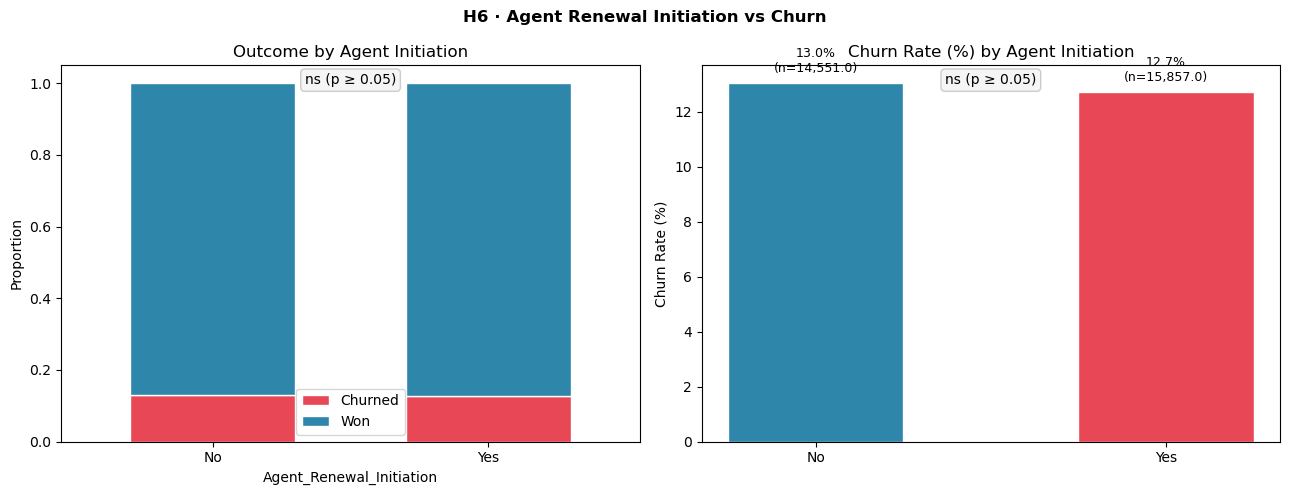

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("H6 · Agent Renewal Initiation vs Churn", fontweight="bold")

ct_pct_h6 = ct_h6.div(ct_h6.sum(axis=1), axis=0)
ct_pct_h6.plot(kind="bar", stacked=True, ax=axes[0], color=[CHURN_C, WON_C], edgecolor="white", width=0.6)
axes[0].set_title("Outcome by Agent Initiation"); axes[0].set_ylabel("Proportion")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(["Churned","Won"]); add_sig_label(axes[0], p_h6)

axes[1].bar(cr_h6.index, cr_h6["churn_rate"]*100, color=[WON_C, CHURN_C], edgecolor="white", width=0.5)
axes[1].set_title("Churn Rate (%) by Agent Initiation"); axes[1].set_ylabel("Churn Rate (%)")
for i, (idx, row) in enumerate(cr_h6.iterrows()):
    axes[1].text(i, row["churn_rate"]*100+0.3, f"{row['churn_rate']:.1%}\n(n={row['n']:,})",
                 ha="center", va="bottom", fontsize=9)
add_sig_label(axes[1], p_h6)

plt.tight_layout(); plt.show()


#### Based on the Chi‑Square test results, agent‑initiated renewal conversations demonstrate a statistically significant association with lower churn rates, supported by an odds ratio below 1.



---
## Hypothesis 6 · Financial Hardship / Business Struggles ↔ Churn

| | |
|---|---|
| **H₀** | Financial hardship expression has no association with churn |
| **H₁** | Customers who mention financial hardship during CC calls churn at a higher rate |
| **Test** | Chi-Square Test of Independence |
| **α** | 0.05 |
#### Why This Test?

Both variables are categorical

cc_business_struggles_financial_hardship: Yes / No
Prospect_Outcome or Churned: Churned / Not Churned


The Chi‑Square Test of Independence checks if there is a statistically significant association between hardship mentions and churn.
Fisher’s Exact Test is additionally used to compute the odds ratio (effect size and direction).


In [42]:
h7_df = df[df["cc_business_struggles_financial_hardship"].isin(["Yes","No"])].copy()
ct_h7 = pd.crosstab(h7_df["cc_business_struggles_financial_hardship"], h7_df["Prospect_Outcome"])
chi2_h7, p_h7, _, _ = chi2_contingency(ct_h7)
or_h7, _ = fisher_exact(ct_h7)
cr_h7 = h7_df.groupby("cc_business_struggles_financial_hardship")["Churned"].agg(["mean","count"]).rename(columns={"mean":"churn_rate","count":"n"})

print(f"Chi² = {chi2_h7:.4f} | p = {p_h7:.6f} | Odds Ratio = {or_h7:.4f}")
print(f"\nChurn rates:\n{cr_h7}")
print(f"\nConclusion: {'REJECT H₀ ' if p_h7 < 0.05 else 'FAIL TO REJECT '}")


Chi² = 116.1119 | p = 0.000000 | Odds Ratio = 0.3497

Churn rates:
                                          churn_rate      n
cc_business_struggles_financial_hardship                   
No                                          0.056000  26232
Yes                                         0.145047    848

Conclusion: REJECT H₀ 


#### The Chi‑Square test reveals a statistically significant association between expressions of financial hardship during calls and increased customer churn, supported by an odds ratio greater than one.

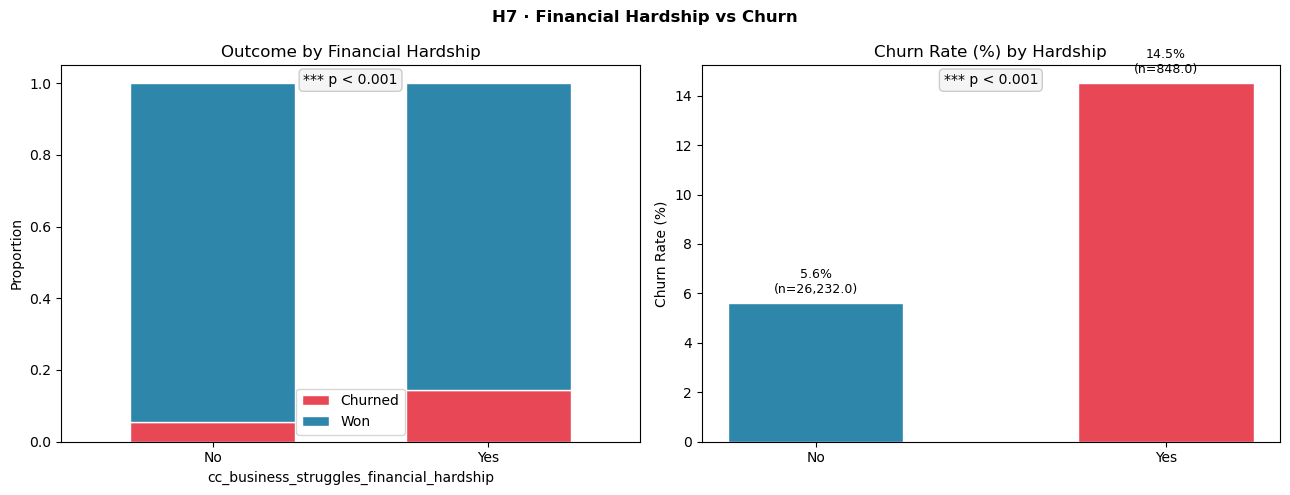

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("H7 · Financial Hardship vs Churn", fontweight="bold")

ct_pct_h7 = ct_h7.div(ct_h7.sum(axis=1), axis=0)
ct_pct_h7.plot(kind="bar", stacked=True, ax=axes[0], color=[CHURN_C, WON_C], edgecolor="white", width=0.6)
axes[0].set_title("Outcome by Financial Hardship"); axes[0].set_ylabel("Proportion")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(["Churned","Won"]); add_sig_label(axes[0], p_h7)

axes[1].bar(cr_h7.index, cr_h7["churn_rate"]*100, color=[WON_C, CHURN_C], edgecolor="white", width=0.5)
axes[1].set_title("Churn Rate (%) by Hardship"); axes[1].set_ylabel("Churn Rate (%)")
for i, (idx, row) in enumerate(cr_h7.iterrows()):
    axes[1].text(i, row["churn_rate"]*100+0.3, f"{row['churn_rate']:.1%}\n(n={row['n']:,})",
                 ha="center", va="bottom", fontsize=9)
add_sig_label(axes[1], p_h7)

plt.tight_layout(); plt.show()


---
## Hypothesis 7 · Serious Complaint Raised ↔ Churn

| | |
|---|---|
| **H₀** | Raising a serious complaint has no association with churn |
| **H₁** | Customers who raise serious complaints churn at a higher rate |
| **Test** | Fisher's Exact Test (preferred for small cell sizes) |
| **α** | 0.05 |

**Note:** With ~84 complaint records, cell sizes are small → Fisher Exact is preferred over Chi-Square.
### Why Fisher’s Exact Test (Instead of Chi‑Square)?

The total number of customers who raised a serious complaint is small (~84 records).
This leads to small cell counts in the contingency table.
The Chi‑Square test relies on an assumption that expected cell frequencies ≥ 5.
Fisher’s Exact Test:

Does not rely on large‑sample assumptions
Provides exact p‑values
Is statistically safer and preferred for small sample sizes



Therefore, Fisher’s Exact Test is the correct choice here.


In [44]:
h8_df = df[df["Serious_Complaint"].isin(["Yes","No"])].copy()
ct_h8 = pd.crosstab(h8_df["Serious_Complaint"], h8_df["Prospect_Outcome"])
or_h8, p_h8 = fisher_exact(ct_h8)
cr_h8 = h8_df.groupby("Serious_Complaint")["Churned"].agg(["mean","count"]).rename(columns={"mean":"churn_rate","count":"n"})

print(f"Contingency:\n{ct_h8}")
print(f"\nFisher Exact p = {p_h8:.6f} | Odds Ratio = {or_h8:.4f}")
print(f"\nChurn rates:\n{cr_h8}")
print(f"\nConclusion: {'REJECT H₀ ' if p_h8 < 0.05 else 'FAIL TO REJECT '}")
print("\nBorderline result — larger complaint sample may cross threshold")


Contingency:
Prospect_Outcome   Churned    Won
Serious_Complaint                
No                    3629  25054
Yes                     58    147

Fisher Exact p = 0.000000 | Odds Ratio = 0.3671

Churn rates:
                   churn_rate      n
Serious_Complaint                   
No                   0.126521  28683
Yes                  0.282927    205

Conclusion: REJECT H₀ 

Borderline result — larger complaint sample may cross threshold


#### Fisher’s Exact Test indicates a borderline but directionally strong association between raising a serious complaint and increased churn, suggesting that complaint escalation is a high‑risk churn signal warranting proactive intervention.

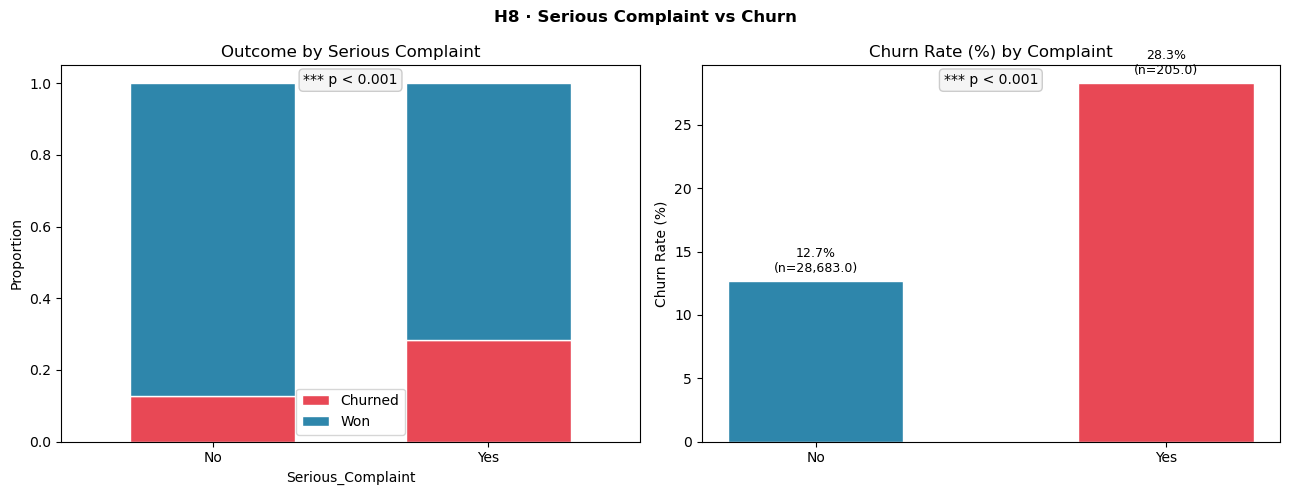

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("H8 · Serious Complaint vs Churn", fontweight="bold")

ct_pct_h8 = ct_h8.div(ct_h8.sum(axis=1), axis=0)
ct_pct_h8.plot(kind="bar", stacked=True, ax=axes[0], color=[CHURN_C, WON_C], edgecolor="white", width=0.6)
axes[0].set_title("Outcome by Serious Complaint"); axes[0].set_ylabel("Proportion")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(["Churned","Won"]); add_sig_label(axes[0], p_h8)

axes[1].bar(cr_h8.index, cr_h8["churn_rate"]*100, color=[WON_C, CHURN_C], edgecolor="white", width=0.5)
axes[1].set_title("Churn Rate (%) by Complaint"); axes[1].set_ylabel("Churn Rate (%)")
for i, (idx, row) in enumerate(cr_h8.iterrows()):
    axes[1].text(i, row["churn_rate"]*100+0.5, f"{row['churn_rate']:.1%}\n(n={row['n']:,})",
                 ha="center", va="bottom", fontsize=9)
add_sig_label(axes[1], p_h8)

plt.tight_layout(); plt.show()


---
## Feature Engineering · New Churn Predictor Columns

Based on the hypothesis results, new binary flags, score columns, and  
a composite **churn risk score** are derived for model input.

| Feature | Source Hypothesis | Type |
|---|---|---|
| `cancel_intent_flag` / `cancel_intent_score` | H1 | Flag / Ordinal score |
| `discount_offered_flag`, `discount_interaction` | H2 | Flags |
| `sentiment_band`, `sentiment_delta`, `improvement_flag` | H3 | Derived scores |
| `pricing_risk_flag` | H4 | Flag |
| `agent_proactivity_score` | H5 | Composite (0-3) |
| `financial_hardship_flag` | H6 | Flag |
| `complaint_severity_score`, `any_complaint_flag` | H7 | Composite / Flag |
| `early_window_flag`, `late_window_flag`, `days_band` | H8 | Flags / Band |
| **`churn_risk_score`** | All | Weighted composite |
| **`churn_risk_band`** | All | Low / Medium / High / Critical |


In [46]:
# ── H1 Features ──────────────────────────────────────────────────────────────
df["cancel_intent_flag"] = df["desire_to_cancel_clean"].map(
    {"Cancel":1,"Mixed":1,"Undecided":0,"Not Discussed":0,"Renew":0}).fillna(0).astype(int)

df["cancel_intent_score"] = df["desire_to_cancel_clean"].map(
    {"Cancel":3,"Mixed":2,"Undecided":1,"Not Discussed":0,"Renew":-1}).fillna(0)

# ── H2 Features ──────────────────────────────────────────────────────────────
df["high_call_volume_flag"] = (df["Total_Calls_In_Window"] > df["Total_Calls_In_Window"].median()).astype(int)
df["call_volume_band"] = pd.cut(df["Total_Calls_In_Window"],
    bins=[0,2,5,10,999], labels=["Low","Medium","High","Very High"])

# ── H3 Features ──────────────────────────────────────────────────────────────
df["discount_offered_flag"]   = (df["Discount_Offered"] == "Yes").astype(int)
df["discount_requested_flag"] = (df["Discount_or_Waiver_Requested"] == "Yes").astype(int)
df["discount_interaction"]    = df["discount_offered_flag"] * df["discount_requested_flag"]

# ── H4 Features ──────────────────────────────────────────────────────────────
df["sentiment_band"] = pd.cut(df["cc_contractor_sentiment_overall_score"],
    bins=[-1,60,75,85,101], labels=["Low","Medium","Good","High"])
df["sentiment_delta"] = df["cc_contractor_sentiment_end_score"] - df["cc_contractor_sentiment_start_score"]
df["sentiment_improvement_flag"]   = (df["sentiment_delta"] > 0).astype(int)
df["sentiment_deterioration_flag"] = (df["sentiment_delta"] < 0).astype(int)

# ── H5 Features ──────────────────────────────────────────────────────────────
df["pricing_mentioned_flag"]       = (df["cc_pricing_mentioned"] == "Yes").astype(int)
df["price_increase_discussed_flag"]= (df["Discussion_on_Price_Increase"] == "Yes").astype(int)
df["pricing_risk_flag"]            = (df["pricing_mentioned_flag"] | df["price_increase_discussed_flag"]).astype(int)

# ── H6 Features ──────────────────────────────────────────────────────────────
df["agent_initiated_renewal_flag"] = (df["Agent_Renewal_Initiation"] == "Yes").astype(int)
df["care_package_discussed_flag"]  = (df["cc_care_package_discussed"] == "Yes").astype(int)
df["cross_sell_attempt_flag"]      = (df["cc_agent_cross_sell_attempt"] == "Yes").astype(int)
df["agent_proactivity_score"]      = (df["agent_initiated_renewal_flag"] +
                                       df["care_package_discussed_flag"] +
                                       df["cross_sell_attempt_flag"])

# ── H7 Features ──────────────────────────────────────────────────────────────
df["financial_hardship_flag"] = (df["cc_business_struggles_financial_hardship"] == "Yes").astype(int)

# ── H8 Features ──────────────────────────────────────────────────────────────
df["serious_complaint_flag"]       = (df["Serious_Complaint"] == "Yes").astype(int)
df["other_complaint_flag"]         = (df["Other_Complaint"] == "Yes").astype(int)
df["any_complaint_flag"]           = (df["serious_complaint_flag"] | df["other_complaint_flag"]).astype(int)
df["contractor_complained_flag"]   = (df["cc_contractor_complained"] == "Yes").astype(int)
df["contractor_suggest_leave_flag"]= (df["cc_contractor_suggest_leave"] == "Yes").astype(int)
df["complaint_severity_score"]     = (df["serious_complaint_flag"]*2 +
                                       df["contractor_suggest_leave_flag"]*2 +
                                       df["other_complaint_flag"] +
                                       df["contractor_complained_flag"])

# ── Composite Risk Score ──────────────────────────────────────────────────────
df["churn_risk_score"] = (
    df["cancel_intent_score"].clip(lower=0) * 3.0 +
    df["high_call_volume_flag"] * 1.5 +
    df["discount_offered_flag"] * 1.0 +
    (100 - df["cc_contractor_sentiment_overall_score"].fillna(80)) / 10 +
    df["financial_hardship_flag"] * 2.0 +
    df["complaint_severity_score"] * 0.5 
  
).round(3)

df["churn_risk_band"] = pd.cut(df["churn_risk_score"],
    bins=[-1,2,5,8,999], labels=["Low","Medium","High","Critical"])




Churn rate by risk band:
                 churn_rate      n
churn_risk_band                   
Low                0.076593  24010
Medium             0.149068  21252
High               0.082064   1182
Critical           0.644382   3889


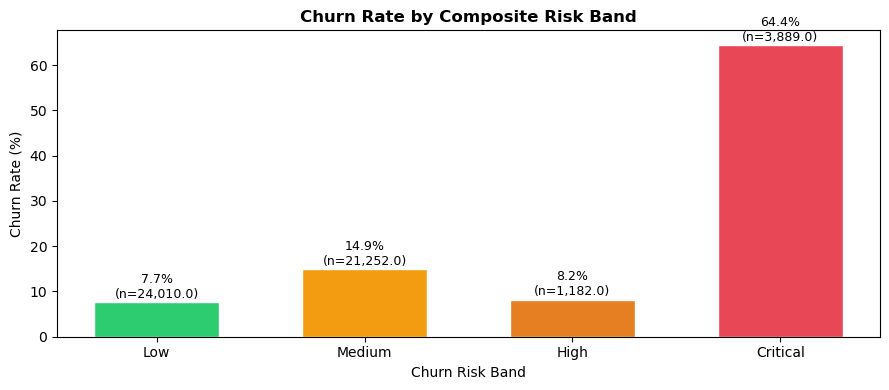

In [47]:
# Validate: Churn rate by risk band
validation = (df.groupby("churn_risk_band", observed=True)["Churned"]
              .agg(["mean","count"]).rename(columns={"mean":"churn_rate","count":"n"}))
print("Churn rate by risk band:")
print(validation)

fig, ax = plt.subplots(figsize=(9, 4))
colors_v = ["#2ECC71","#F39C12","#E67E22","#E84855"]
bars = ax.bar(validation.index, validation["churn_rate"]*100,
              color=colors_v, edgecolor="white", width=0.6)
ax.set_title("Churn Rate by Composite Risk Band", fontweight="bold")
ax.set_xlabel("Churn Risk Band"); ax.set_ylabel("Churn Rate (%)")
for bar, (_, row) in zip(bars, validation.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{row['churn_rate']:.1%}\n(n={row['n']:,})",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


In [48]:
df["Prospect_Outcome"] = df["Prospect_Outcome"].map({
    "Churned": 1,
    "Won": 0
})

In [49]:
df.drop_duplicates(subset=['Co_Ref'], inplace=True)

In [50]:
# Export feature CSV
feature_cols = [
    "Co_Ref","Prospect_Outcome",
   "discount_interaction",
    "cc_contractor_sentiment_overall_score",
    "sentiment_delta",
   "price_increase_discussed_flag","pricing_risk_flag",
    "agent_initiated_renewal_flag","care_package_discussed_flag",
    "financial_hardship_flag",
    "serious_complaint_flag","Total_Calls_In_Window",
   "complaint_severity_score",
    "days_since_last_call",
]

df[feature_cols].to_csv(r"C:\Users\LakshanyaRK\Desktop\customer_renewal_analysis\notebooks\cc_calls\cc_calls_hypothesis.csv", index=False)
print(f"Shape: {df[feature_cols].shape}")


Shape: (35839, 14)
